# Unified Binary Pipeline Full Run

This notebook runs the full binary mammography pipeline end to end with visible progress and then summarizes the outputs.

In [1]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.2.2+cu121
12.1
True
1
NVIDIA GeForce RTX 3060


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
from pathlib import Path

REPO_DIR = Path.cwd()
DATASET_BASE = Path("C:/Users/Roofu/Downloads/grading-cbisddsm-unified/grading-cbisddsm-unified/birads_dataset")
MANIFEST_CSV = None  # Set to a CSV path to reuse an existing manifest
CLASSIFIER_CHECKPOINT =  Path("C:/Users/Roofu/Downloads/grading-cbisddsm-unified/grading-cbisddsm-unified/output/binary_classifier_from_precomputed_best.pth") # Set explicitly if needed
OUTPUT_DIR = REPO_DIR / 'binary_full_run_notebook'
LIMIT = None  # Set to an integer for a quick smoke test
MAX_LONG_SIDE = 1536
DEVICE = None  # Example: 'cuda' or 'cpu'

print(f'REPO_DIR={REPO_DIR}')
print(f'DATASET_BASE={DATASET_BASE}')
print(f'OUTPUT_DIR={OUTPUT_DIR}')
print(f'LIMIT={LIMIT}')


REPO_DIR=c:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\code
DATASET_BASE=C:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\birads_dataset
OUTPUT_DIR=c:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\code\binary_full_run_notebook
LIMIT=None


In [4]:
import json
from time import perf_counter, strftime

import pandas as pd
from scipy.ndimage import shift
from skimage.transform import resize

from alignment import align_mlo_to_cc
from classification import BiradsClassifier, birads_to_binary_label
from correspondence import compute_cross_view_correspondence
from data import extract_breast_mask, load_grayscale_image, preprocess_mammogram
from detection import detect_lesion_bbox
from segmentation import segment_lesion
from run_kaggle_full_pipeline import (
    bbox_to_mask,
    build_kaggle_manifest,
    center_distance,
    default_classifier_checkpoint,
    dice_score,
    iou_score,
    load_roi_union,
    overlay_detection,
    overlay_gt_comparison,
    overlay_segmentation,
    precision_recall,
    resize_long_side,
    save_alignment_overlay,
)

LABEL_NAMES = {
    0: 'birads_0_1_2_3',
    1: 'birads_4_5',
}


def log_progress(message: str) -> None:
    timestamp = strftime('%Y-%m-%d %H:%M:%S')
    print(f'[{timestamp}] {message}', flush=True)


def safe_div(numerator: float, denominator: float) -> float:
    return float(numerator / denominator) if denominator else 0.0


def compute_binary_classification_metrics(y_true: list[int], y_pred: list[int]) -> dict:
    labels = [0, 1]
    matrix = [[0, 0], [0, 0]]
    for yt, yp in zip(y_true, y_pred):
        matrix[int(yt)][int(yp)] += 1

    total = len(y_true)
    correct = matrix[0][0] + matrix[1][1]
    class_metrics = {}
    recalls = []
    f1s = []
    weighted_f1_sum = 0.0

    for label in labels:
        tp = matrix[label][label]
        fp = sum(matrix[row][label] for row in labels if row != label)
        fn = sum(matrix[label][col] for col in labels if col != label)
        tn = total - tp - fp - fn
        support = sum(matrix[label])
        predicted_count = matrix[0][label] + matrix[1][label]

        precision = safe_div(tp, tp + fp)
        recall = safe_div(tp, tp + fn)
        specificity = safe_div(tn, tn + fp)
        npv = safe_div(tn, tn + fn)
        f1 = safe_div(2.0 * precision * recall, precision + recall) if (precision + recall) else 0.0
        prevalence = safe_div(support, total)

        recalls.append(recall)
        f1s.append(f1)
        weighted_f1_sum += f1 * support
        class_metrics[str(label)] = {
            'label_name': LABEL_NAMES[label],
            'support': int(support),
            'predicted_count': int(predicted_count),
            'tp': int(tp),
            'fp': int(fp),
            'fn': int(fn),
            'tn': int(tn),
            'precision': precision,
            'recall': recall,
            'specificity': specificity,
            'npv': npv,
            'f1': f1,
            'prevalence': prevalence,
        }

    return {
        'labels': labels,
        'label_names': [LABEL_NAMES[label] for label in labels],
        'confusion_matrix': matrix,
        'num_samples': int(total),
        'accuracy': safe_div(correct, total),
        'balanced_accuracy': float(sum(recalls) / len(recalls)) if recalls else 0.0,
        'macro_f1': float(sum(f1s) / len(f1s)) if f1s else 0.0,
        'weighted_f1': safe_div(weighted_f1_sum, total),
        'class_metrics': class_metrics,
    }


def ensure_binary_manifest(manifest: pd.DataFrame) -> pd.DataFrame:
    if 'binary_label' in manifest.columns:
        return manifest
    manifest = manifest.copy()
    manifest['binary_label'] = manifest['birads_label'].map(birads_to_binary_label)
    return manifest


In [5]:
import cv2
import numpy as np

def prepare_gt_mask_for_eval(gt_mask: np.ndarray, pred_mask: np.ndarray) -> np.ndarray:
    gt = (gt_mask > 0).astype(np.uint8)
    pred_h, pred_w = pred_mask.shape

    if gt.shape != pred_mask.shape:
        gt = cv2.resize(gt.astype(np.uint8), (pred_w, pred_h), interpolation=cv2.INTER_NEAREST)

    gt = (gt > 0).astype(np.uint8)
    return gt

In [6]:
run_started = perf_counter()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for name in ['manifests', 'detection', 'segmentation', 'gt_comparison', 'alignment', 'correspondence', 'classification', 'metrics']:
    (OUTPUT_DIR / name).mkdir(parents=True, exist_ok=True)

log_progress('Starting binary pipeline notebook run')
log_progress(f'Dataset base: {DATASET_BASE}')
log_progress(f'Output dir: {OUTPUT_DIR}')

if MANIFEST_CSV:
    log_progress(f'Loading manifest from {MANIFEST_CSV}')
    manifest = ensure_binary_manifest(pd.read_csv(MANIFEST_CSV))
    if LIMIT:
        manifest = manifest.iloc[:LIMIT].copy()
    (OUTPUT_DIR / 'manifests' / 'paired_kaggle_manifest.csv').write_text(manifest.to_csv(index=False))
else:
    log_progress('Building manifest from dataset')
    manifest = build_kaggle_manifest(DATASET_BASE, OUTPUT_DIR / 'manifests', pair_limit=LIMIT)
    if LIMIT:
        manifest = manifest.iloc[:LIMIT].copy()

total_samples = len(manifest)
checkpoint_path = CLASSIFIER_CHECKPOINT or default_classifier_checkpoint()
log_progress(f'Manifest ready with {total_samples} samples')
log_progress(f'Initializing classifier from {checkpoint_path}')
classifier = BiradsClassifier(checkpoint_path, device=DEVICE)

[2026-04-05 09:09:38] Starting binary pipeline notebook run
[2026-04-05 09:09:38] Dataset base: C:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\birads_dataset
[2026-04-05 09:09:38] Output dir: c:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\code\binary_full_run_notebook
[2026-04-05 09:09:38] Building manifest from dataset
[2026-04-05 09:13:07] Manifest ready with 1324 samples
[2026-04-05 09:13:07] Initializing classifier from C:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\output\binary_classifier_from_precomputed_best.pth
[Classifier] checkpoint_path=C:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\output\binary_classifier_from_precomputed_best.pth
[Classifier] exists=True


sample_id: P_00004_LEFT
side: LEFT
checkpoint: C:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\output\localizer_unet.pth
checkpoint exists: True
[Localizer] loading model...
SEGMENTATION CHECKPOINT PATH: C:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\output\localizer_unet.pth
[Localizer] keys: ['enc1.block.0.weight', 'enc1.block.1.weight', 'enc1.block.1.bias', 'enc1.block.1.running_mean', 'enc1.block.1.running_var', 'enc1.block.1.num_batches_tracked', 'enc1.block.3.weight', 'enc1.block.4.weight', 'enc1.block.4.bias', 'enc1.block.4.running_mean', 'enc1.block.4.running_var', 'enc1.block.4.num_batches_tracked', 'enc2.block.0.weight', 'enc2.block.1.weight', 'enc2.block.1.bias', 'enc2.block.1.running_mean', 'enc2.block.1.running_var', 'enc2.block.1.num_batches_tracked', 'enc2.block.3.weight', 'enc2.block.4.weight', 'enc2.block.4.bias', 'enc2.block.4.running_mean', 'enc2.block.4.running_var', 'enc2.block.4.num_batches_tracked', 'enc3.blo

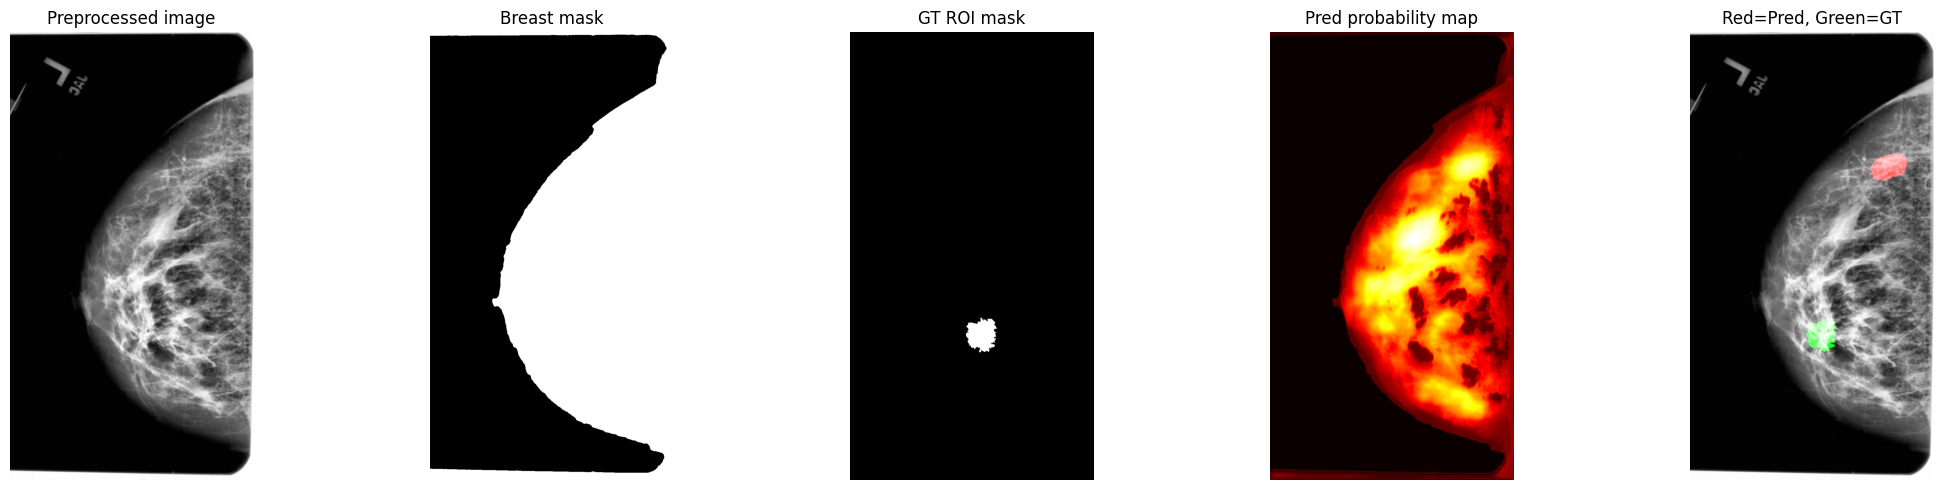

In [7]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import localizer

# pick one sample
row = manifest.iloc[1]
side = str(row["breast_side"]).strip().upper()
sample_id = str(row["sample_id"])

print("sample_id:", sample_id)
print("side:", side)
print("checkpoint:", localizer.default_localizer_checkpoint())
print("checkpoint exists:", Path(localizer.default_localizer_checkpoint()).exists())

# load image the same way pipeline does
cc_raw_original = load_grayscale_image(row["cc_image_path"], flip_right=side == "RIGHT")
cc_raw = resize_long_side(cc_raw_original, MAX_LONG_SIDE)
cc_gt_mask = load_roi_union(row["cc_roi_entries"], side, cc_raw, cc_raw_original.shape)

cc_img = preprocess_mammogram(cc_raw)
cc_breast = extract_breast_mask(cc_img)

# clear cache so we know it reloads once
localizer._MODEL_CACHE.clear()

# run localization directly
pred = localizer.predict_localization(
    cc_img,
    cc_breast,
    checkpoint_path=localizer.default_localizer_checkpoint(),
    input_size=512,   # match trained checkpoint
)

print("pred is None:", pred is None)
if pred is not None:
    print("pred mask sum:", int(pred.binary_mask.sum()))
    print("pred confidence:", float(pred.confidence))
    print("prob max:", float(pred.probability_map.max()))
    active = pred.probability_map[cc_breast > 0]
    print("prob mean on breast:", float(active.mean()) if active.size else 0.0)

    gt = (cc_gt_mask > 0).astype(np.uint8)
    pr = pred.binary_mask.astype(np.uint8)

    inter = (gt & pr).sum()
    denom = gt.sum() + pr.sum()
    dice = (2 * inter / denom) if denom > 0 else 1.0
    iou = (inter / ((gt | pr).sum())) if (gt | pr).sum() > 0 else 1.0

    print("single-sample dice:", float(dice))
    print("single-sample iou:", float(iou))

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    axes[0].imshow(cc_img, cmap="gray")
    axes[0].set_title("Preprocessed image")
    axes[0].axis("off")

    axes[1].imshow(cc_breast, cmap="gray")
    axes[1].set_title("Breast mask")
    axes[1].axis("off")

    axes[2].imshow(cc_gt_mask, cmap="gray")
    axes[2].set_title("GT ROI mask")
    axes[2].axis("off")

    axes[3].imshow(pred.probability_map, cmap="hot")
    axes[3].set_title("Pred probability map")
    axes[3].axis("off")

    overlay = np.stack([cc_img, cc_img, cc_img], axis=-1)
    overlay[..., 1] = np.maximum(overlay[..., 1], gt.astype(np.float32))  # green GT
    overlay[..., 0] = np.maximum(overlay[..., 0], pr.astype(np.float32))  # red pred

    axes[4].imshow(overlay)
    axes[4].set_title("Red=Pred, Green=GT")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
per_sample = []
y_true = []
y_pred = []

for sample_index, (_, row) in enumerate(manifest.iterrows(), start=1):
    sample_started = perf_counter()
    side = str(row['breast_side']).strip().upper()
    sample_id = str(row['sample_id'])

    log_progress(f'[{sample_index}/{total_samples}] {sample_id}: loading images')
    cc_raw_original = load_grayscale_image(row['cc_image_path'], flip_right=side == 'RIGHT')
    mlo_raw_original = load_grayscale_image(row['mlo_image_path'], flip_right=side == 'RIGHT')
    cc_raw = resize_long_side(cc_raw_original, MAX_LONG_SIDE)
    mlo_raw = resize_long_side(mlo_raw_original, MAX_LONG_SIDE)
    cc_gt_mask = load_roi_union(row['cc_roi_entries'], side, cc_raw, cc_raw_original.shape)
    mlo_gt_mask = load_roi_union(row['mlo_roi_entries'], side, mlo_raw, mlo_raw_original.shape)

    log_progress(f'[{sample_index}/{total_samples}] {sample_id}: preprocessing and breast masking')
    cc_img = preprocess_mammogram(cc_raw)
    mlo_img = preprocess_mammogram(mlo_raw)
    cc_breast = extract_breast_mask(cc_img)
    mlo_breast = extract_breast_mask(mlo_img)

    log_progress(f'[{sample_index}/{total_samples}] {sample_id}: segmentation and detection')
    cc_seg = segment_lesion(cc_img, cc_breast)
    cc_det = detect_lesion_bbox(cc_img, cc_breast)
    mlo_seg = segment_lesion(mlo_img, mlo_breast)
    mlo_det = detect_lesion_bbox(mlo_img, mlo_breast)

    log_progress(f'[{sample_index}/{total_samples}] {sample_id}: correspondence and alignment')
    correspondence = compute_cross_view_correspondence(cc_seg.mask, mlo_seg.mask, cc_img, mlo_img)
    alignment = align_mlo_to_cc(cc_img, mlo_img, cc_seg.mask, mlo_seg.mask)

    mlo_seg_resized = resize(
        mlo_seg.mask.astype(float),
        cc_seg.mask.shape,
        preserve_range=True,
        order=0,
        anti_aliasing=False,
    ) > 0.5
    aligned_mlo_mask = shift(
        mlo_seg_resized.astype(float),
        shift=(alignment.affine_matrix[1][2], alignment.affine_matrix[0][2]),
        order=0,
        mode='constant',
        cval=0.0,
    ) > 0.5

    log_progress(f'[{sample_index}/{total_samples}] {sample_id}: classification')
    cls = classifier.predict(
        cc_img,
        alignment.aligned_image,
        cc_seg.mask,
        aligned_mlo_mask.astype('uint8'),
        cc_det.bbox_xywh,
        mlo_det.bbox_xywh,
    )

    true_binary = int(row['binary_label'])
    pred_binary = int(cls.predicted_binary_label)
    y_true.append(true_binary)
    y_pred.append(pred_binary)

    cc_det_mask = bbox_to_mask(cc_det.bbox_xywh, cc_seg.mask.shape)
    mlo_det_mask = bbox_to_mask(mlo_det.bbox_xywh, mlo_seg.mask.shape)
    cc_precision, cc_recall = precision_recall(cc_seg.mask, cc_gt_mask)
    mlo_precision, mlo_recall = precision_recall(mlo_seg.mask, mlo_gt_mask)

    sample_metrics = {
        'sample_id': sample_id,
        'patient_id': row['patient_id'],
        'true_birads': int(row['birads_label']),
        'true_binary_label': true_binary,
        'predicted_birads': int(cls.predicted_birads),
        'predicted_binary_label': pred_binary,
        'predicted_binary_name': LABEL_NAMES[pred_binary],
        'classifier_source': cls.source,
        'cc_seg_dice_vs_roi': dice_score(cc_seg.mask, cc_gt_mask),
        'cc_seg_iou_vs_roi': iou_score(cc_seg.mask, cc_gt_mask),
        'cc_seg_precision_vs_roi': cc_precision,
        'cc_seg_recall_vs_roi': cc_recall,
        'mlo_seg_dice_vs_roi': dice_score(mlo_seg.mask, mlo_gt_mask),
        'mlo_seg_iou_vs_roi': iou_score(mlo_seg.mask, mlo_gt_mask),
        'mlo_seg_precision_vs_roi': mlo_precision,
        'mlo_seg_recall_vs_roi': mlo_recall,
        'cc_det_seg_iou': iou_score(cc_det_mask, cc_seg.mask),
        'mlo_det_seg_iou': iou_score(mlo_det_mask, mlo_seg.mask),
        'cc_detection_confidence': float(cc_det.confidence),
        'mlo_detection_confidence': float(mlo_det.confidence),
        'correspondence_centroid_distance_px': float(correspondence.centroid_distance_px),
        'alignment_dice_before': dice_score(cc_seg.mask, mlo_seg_resized),
        'alignment_dice_after': dice_score(cc_seg.mask, aligned_mlo_mask),
        'alignment_centroid_distance_before': center_distance(cc_seg.mask, mlo_seg_resized),
        'alignment_centroid_distance_after': center_distance(cc_seg.mask, aligned_mlo_mask),
        'binary_probability': float(cls.binary_probability),
        #'ordinal_scores': json.dumps(cls.ordinal_scores),
    }
    per_sample.append(sample_metrics)

    log_progress(f'[{sample_index}/{total_samples}] {sample_id}: writing outputs')
    overlay_detection(cc_img, cc_det.bbox_xywh, OUTPUT_DIR / 'detection' / f'{sample_id}_CC_detection.png')
    overlay_detection(mlo_img, mlo_det.bbox_xywh, OUTPUT_DIR / 'detection' / f'{sample_id}_MLO_detection.png')
    overlay_segmentation(cc_img, cc_seg.mask, OUTPUT_DIR / 'segmentation' / f'{sample_id}_CC_segmentation.png')
    overlay_segmentation(mlo_img, mlo_seg.mask, OUTPUT_DIR / 'segmentation' / f'{sample_id}_MLO_segmentation.png')
    overlay_gt_comparison(cc_img, cc_seg.mask, cc_gt_mask, OUTPUT_DIR / 'gt_comparison' / f'{sample_id}_CC_gt_comparison.png')
    overlay_gt_comparison(mlo_img, mlo_seg.mask, mlo_gt_mask, OUTPUT_DIR / 'gt_comparison' / f'{sample_id}_MLO_gt_comparison.png')
    save_alignment_overlay(cc_img, alignment.aligned_image, OUTPUT_DIR / 'alignment' / f'{sample_id}_alignment_overlay.png')
    (OUTPUT_DIR / 'correspondence' / f'{sample_id}_correspondence.json').write_text(json.dumps(correspondence.to_dict(), indent=2))
    (OUTPUT_DIR / 'classification' / f'{sample_id}_classification.json').write_text(
        json.dumps(
            {
                'sample_id': sample_id,
                'true_birads': int(row['birads_label']),
                'true_binary_label': true_binary,
                'true_binary_name': LABEL_NAMES[true_binary],
                'predicted_birads': int(cls.predicted_birads),
                'predicted_binary_label': pred_binary,
                'predicted_binary_name': LABEL_NAMES[pred_binary],
                'binary_probability': float(cls.binary_probability),
                #'ordinal_scores': cls.ordinal_scores,
                'source': cls.source,
            },
            indent=2,
        )
    )
    log_progress(
        f'[{sample_index}/{total_samples}] {sample_id}: done in {perf_counter() - sample_started:.1f}s '
        f'(pred_binary={pred_binary}, source={cls.source})'
    )

log_progress('Writing aggregate metrics')
per_sample_df = pd.DataFrame(per_sample)
per_sample_df.to_csv(OUTPUT_DIR / 'metrics' / 'per_sample_metrics.csv', index=False)

aggregate = {
    'dataset_base': str(DATASET_BASE),
    'classification_target': 'binary_birads_0_3_vs_4_5',
    'classification_report': compute_binary_classification_metrics(y_true, y_pred),
    'mean_cc_seg_dice_vs_roi': float(per_sample_df['cc_seg_dice_vs_roi'].mean()) if not per_sample_df.empty else None,
    'mean_mlo_seg_dice_vs_roi': float(per_sample_df['mlo_seg_dice_vs_roi'].mean()) if not per_sample_df.empty else None,
    'mean_cc_det_seg_iou': float(per_sample_df['cc_det_seg_iou'].mean()) if not per_sample_df.empty else None,
    'mean_mlo_det_seg_iou': float(per_sample_df['mlo_det_seg_iou'].mean()) if not per_sample_df.empty else None,
    'mean_alignment_dice_before': float(per_sample_df['alignment_dice_before'].mean()) if not per_sample_df.empty else None,
    'mean_alignment_dice_after': float(per_sample_df['alignment_dice_after'].mean()) if not per_sample_df.empty else None,
    'mean_alignment_centroid_distance_before': float(per_sample_df['alignment_centroid_distance_before'].dropna().mean()) if not per_sample_df.empty else None,
    'mean_alignment_centroid_distance_after': float(per_sample_df['alignment_centroid_distance_after'].dropna().mean()) if not per_sample_df.empty else None,
}
(OUTPUT_DIR / 'metrics' / 'aggregate_metrics.json').write_text(json.dumps(aggregate, indent=2))
log_progress(f'Run finished in {perf_counter() - run_started:.1f}s')
aggregate


[2026-04-05 09:13:13] [1/1324] P_00001_LEFT: loading images
[2026-04-05 09:13:13] [1/1324] P_00001_LEFT: preprocessing and breast masking
[2026-04-05 09:13:14] [1/1324] P_00001_LEFT: segmentation and detection
[Localizer] loading model...
SEGMENTATION CHECKPOINT PATH: C:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\output\localizer_unet.pth
[Segmentation] using learned model: True
[Localizer] loading model...
SEGMENTATION CHECKPOINT PATH: C:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\output\localizer_unet.pth
[Localizer] loading model...
SEGMENTATION CHECKPOINT PATH: C:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\output\localizer_unet.pth
[Segmentation] using learned model: True
[Localizer] loading model...
SEGMENTATION CHECKPOINT PATH: C:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\output\localizer_unet.pth
[2026-04-05 09:13:15] [1/1324] P_00001_LEFT: correspondence and alig

{'dataset_base': 'C:\\Users\\Roofu\\Downloads\\grading-cbisddsm-unified\\grading-cbisddsm-unified\\birads_dataset',
 'classification_target': 'binary_birads_0_3_vs_4_5',
 'classification_report': {'labels': [0, 1],
  'label_names': ['birads_0_1_2_3', 'birads_4_5'],
  'confusion_matrix': [[310, 129], [183, 702]],
  'num_samples': 1324,
  'accuracy': 0.7643504531722054,
  'balanced_accuracy': 0.74968534033435,
  'macro_f1': 0.7417089348419821,
  'weighted_f1': 0.7674694378401444,
  'class_metrics': {'0': {'label_name': 'birads_0_1_2_3',
    'support': 439,
    'predicted_count': 493,
    'tp': 310,
    'fp': 183,
    'fn': 129,
    'tn': 702,
    'precision': 0.6288032454361054,
    'recall': 0.7061503416856492,
    'specificity': 0.7932203389830509,
    'npv': 0.8447653429602888,
    'f1': 0.6652360515021459,
    'prevalence': 0.33157099697885195},
   '1': {'label_name': 'birads_4_5',
    'support': 885,
    'predicted_count': 831,
    'tp': 702,
    'fp': 129,
    'fn': 183,
    'tn': 

In [9]:
import json

metrics_path = OUTPUT_DIR / 'metrics' / 'aggregate_metrics.json'
per_sample_path = OUTPUT_DIR / 'metrics' / 'per_sample_metrics.csv'

print(metrics_path)
print(per_sample_path)

with open(metrics_path) as f:
    aggregate = json.load(f)
aggregate


c:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\code\binary_full_run_notebook\metrics\aggregate_metrics.json
c:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\code\binary_full_run_notebook\metrics\per_sample_metrics.csv


{'dataset_base': 'C:\\Users\\Roofu\\Downloads\\grading-cbisddsm-unified\\grading-cbisddsm-unified\\birads_dataset',
 'classification_target': 'binary_birads_0_3_vs_4_5',
 'classification_report': {'labels': [0, 1],
  'label_names': ['birads_0_1_2_3', 'birads_4_5'],
  'confusion_matrix': [[310, 129], [183, 702]],
  'num_samples': 1324,
  'accuracy': 0.7643504531722054,
  'balanced_accuracy': 0.74968534033435,
  'macro_f1': 0.7417089348419821,
  'weighted_f1': 0.7674694378401444,
  'class_metrics': {'0': {'label_name': 'birads_0_1_2_3',
    'support': 439,
    'predicted_count': 493,
    'tp': 310,
    'fp': 183,
    'fn': 129,
    'tn': 702,
    'precision': 0.6288032454361054,
    'recall': 0.7061503416856492,
    'specificity': 0.7932203389830509,
    'npv': 0.8447653429602888,
    'f1': 0.6652360515021459,
    'prevalence': 0.33157099697885195},
   '1': {'label_name': 'birads_4_5',
    'support': 885,
    'predicted_count': 831,
    'tp': 702,
    'fp': 129,
    'fn': 183,
    'tn': 

In [10]:
per_sample_df = pd.read_csv(OUTPUT_DIR / 'metrics' / 'per_sample_metrics.csv')
per_sample_df.head()


,sample_id,patient_id,true_birads,true_binary_label,predicted_birads,predicted_binary_label,predicted_binary_name,classifier_source,cc_seg_dice_vs_roi,cc_seg_iou_vs_roi,...,cc_det_seg_iou,mlo_det_seg_iou,cc_detection_confidence,mlo_detection_confidence,correspondence_centroid_distance_px,alignment_dice_before,alignment_dice_after,alignment_centroid_distance_before,alignment_centroid_distance_after,binary_probability
0,P_00001_LEFT,P_00001,4,1,4,1,birads_4_5,cnn_cross_attention_binary,0.827857,0.706276,...,0.794730,0.552806,1.0,1.0,374.312938,0.0,0.767986,249.063894,0.466599,0.688082
1,P_00004_LEFT,P_00004,4,1,4,1,birads_4_5,cnn_cross_attention_binary,0.000000,0.000000,...,0.723109,0.581582,1.0,1.0,292.992465,0.0,0.893075,207.873870,0.495129,0.965094
2,P_00005_RIGHT,P_00005,3,0,4,1,birads_4_5,cnn_cross_attention_binary,0.008167,0.004100,...,0.440315,0.526583,1.0,1.0,544.913630,0.0,0.537769,461.389933,0.257091,0.925272
3,P_00007_LEFT,P_00007,4,1,4,1,birads_4_5,cnn_cross_attention_binary,0.202194,0.112467,...,0.685018,0.738426,1.0,1.0,535.632657,0.0,0.827393,519.244610,0.412693,0.996028
4,P_00008_LEFT,P_00008,2,0,4,1,birads_4_5,cnn_cross_attention_binary,0.000000,0.000000,...,0.675229,0.581807,1.0,1.0,788.177812,0.0,0.843190,560.718406,0.539226,0.853440


Showing up to 3 alignment overlays:
c:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\code\binary_full_run_notebook\alignment\P_00001_LEFT_alignment_overlay.png


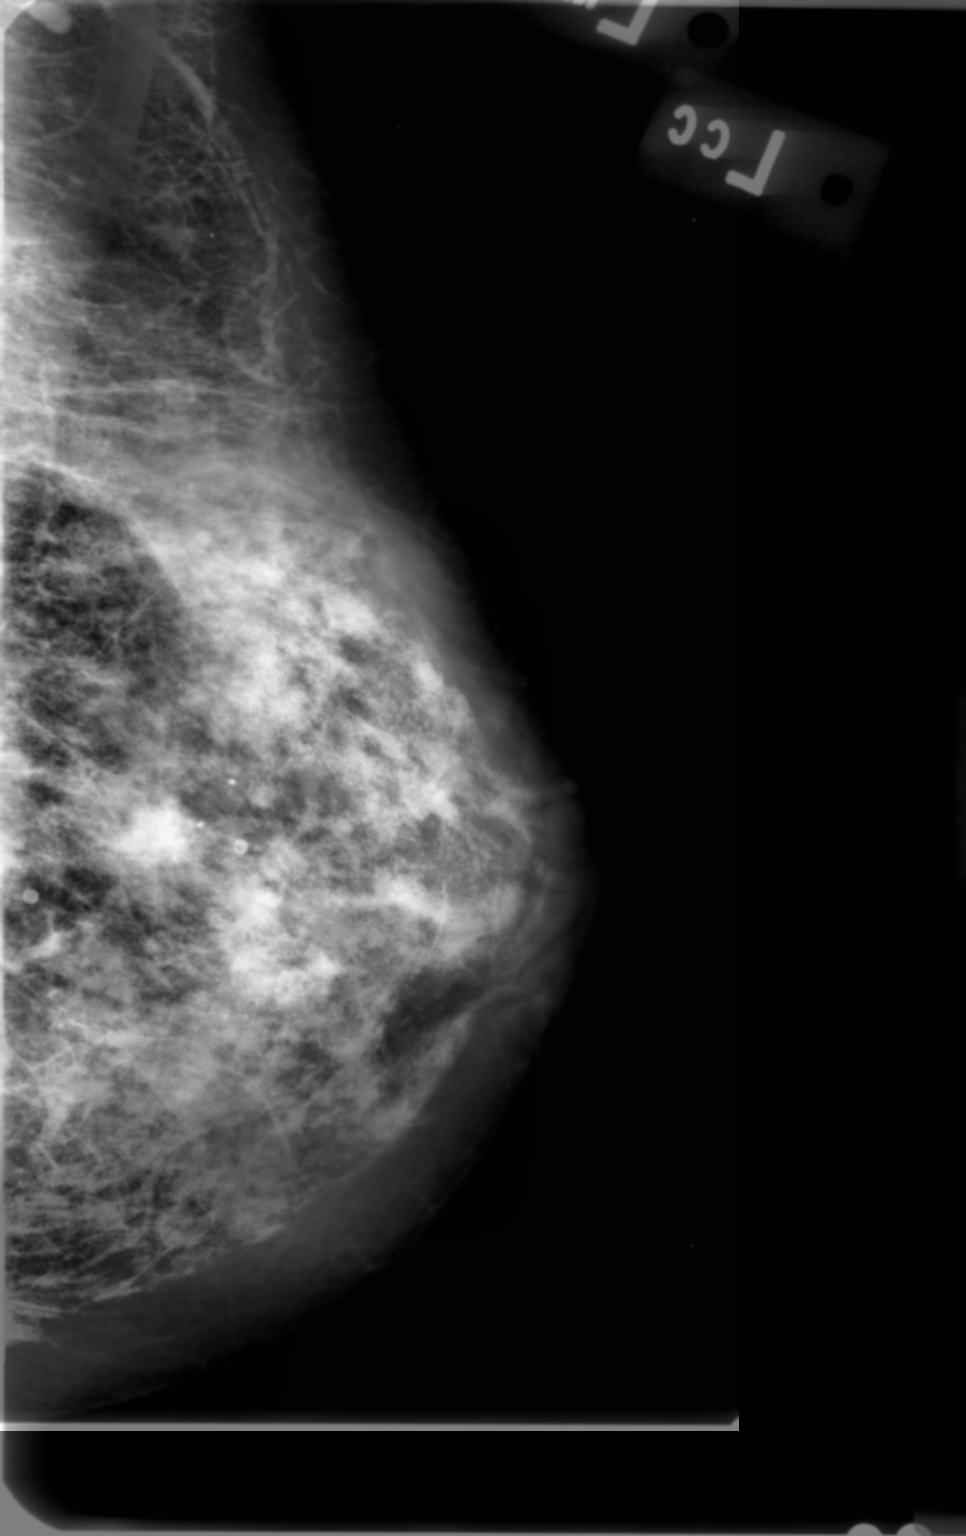

c:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\code\binary_full_run_notebook\alignment\P_00004_LEFT_alignment_overlay.png


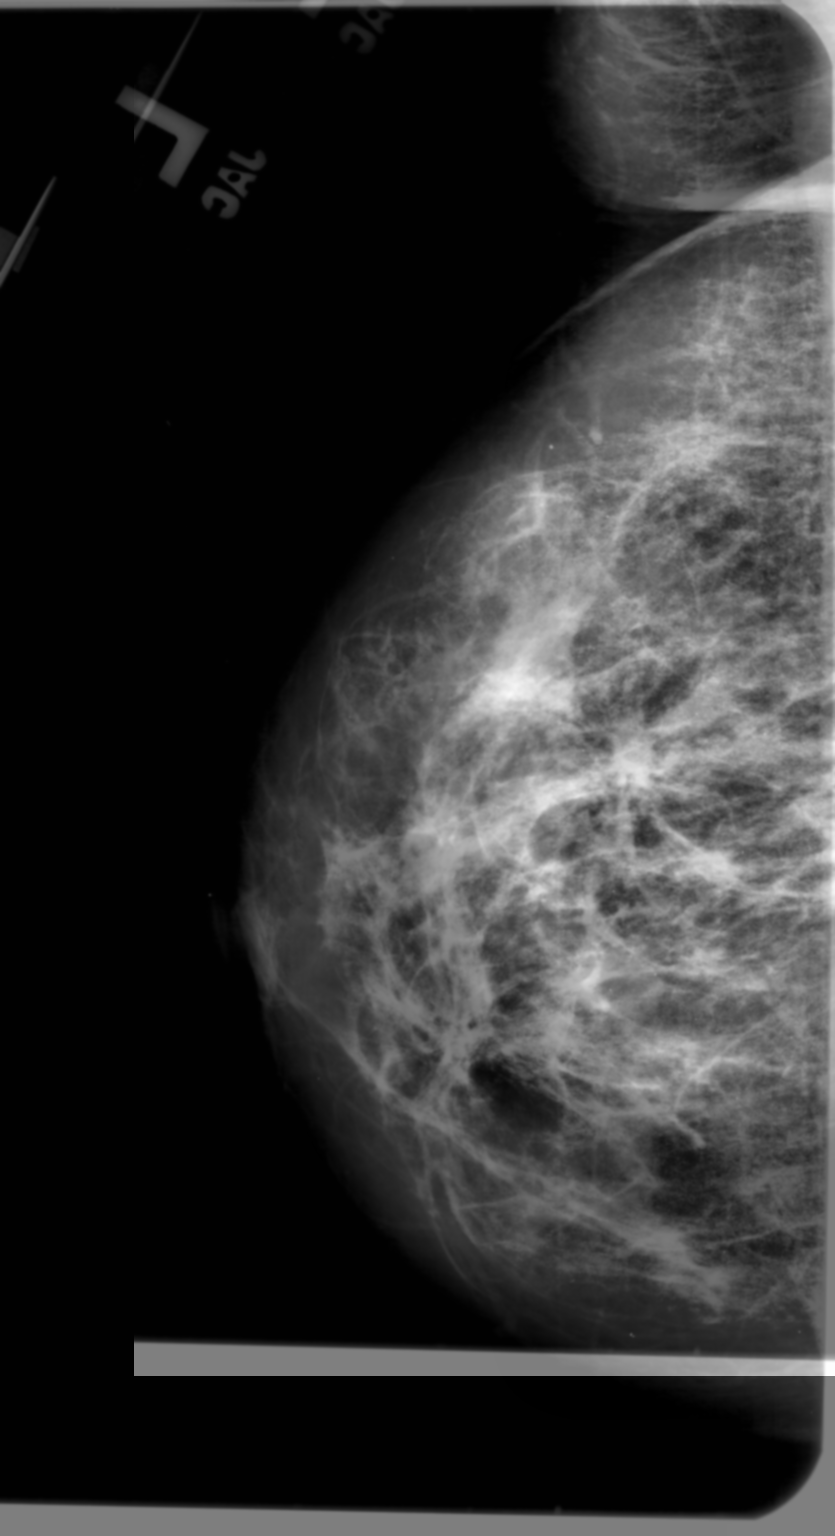

c:\Users\Roofu\Downloads\grading-cbisddsm-unified\grading-cbisddsm-unified\code\binary_full_run_notebook\alignment\P_00005_RIGHT_alignment_overlay.png


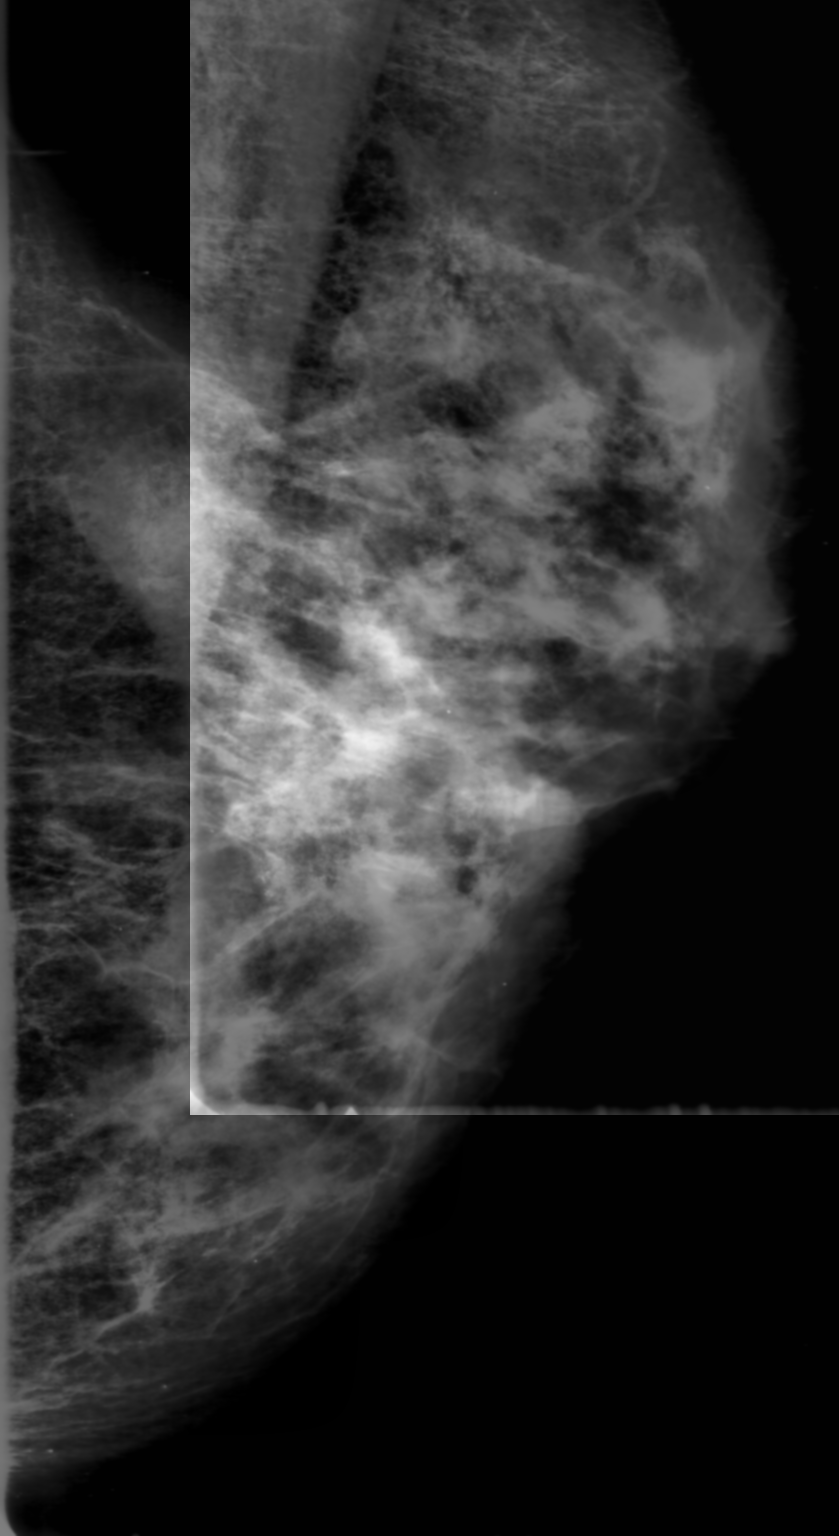

In [11]:
from IPython.display import Image as IPyImage, display

sample_images = sorted((OUTPUT_DIR / 'alignment').glob('*.png'))[:3]
print('Showing up to 3 alignment overlays:')
for path in sample_images:
    print(path)
    display(IPyImage(filename=str(path)))


In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix

thresholds = np.arange(0.30, 0.86, 0.05)

results = []

y_true = per_sample_df["true_binary_label"].values
probs = per_sample_df["binary_probability"].values

for t in thresholds:
    y_pred = (probs >= t).astype(int)

    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    results.append({
        "threshold": t,
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1,
        "tn": cm[0][0],
        "fp": cm[0][1],
        "fn": cm[1][0],
        "tp": cm[1][1],
        "pred_zeros": int((y_pred == 0).sum()),
        "pred_ones": int((y_pred == 1).sum()),
    })

threshold_df = pd.DataFrame(results).sort_values(
    ["balanced_accuracy", "macro_f1"], ascending=False
)

threshold_df.head(10)

,threshold,balanced_accuracy,macro_f1,tn,fp,fn,tp,pred_zeros,pred_ones
7,0.65,0.752134,0.734730,331,108,221,664,552,772
6,0.60,0.752062,0.738544,323,116,205,680,528,796
5,0.55,0.751443,0.740634,317,122,194,691,511,813
8,0.70,0.751077,0.729409,339,100,239,646,578,746
4,0.50,0.749685,0.741709,310,129,183,702,493,831
10,0.80,0.744468,0.711212,358,81,289,596,647,677
9,0.75,0.744333,0.719037,343,96,259,626,602,722
3,0.45,0.739937,0.736722,294,145,168,717,462,862
2,0.40,0.730771,0.731168,280,159,156,729,436,888
11,0.85,0.729833,0.689713,364,75,327,558,691,633
